# Drive mounting

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/P9/Src')

Mounted at /content/drive


# Importing packages

In [2]:
import os
import glob
import json
import random
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, concatenate,
    Conv2DTranspose, BatchNormalization, Activation
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory Growth activée sur {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

✅ Memory Growth activée sur 1 GPU(s)


# Chargement des données

In [4]:
isic_dir_drive = "/content/drive/MyDrive/P9/Src/Data/ISIC2018"
local_base_dir = "/content/P9/Data/ISIC2018"

zip_files = glob.glob(os.path.join(isic_dir_drive, "**/*.zip"), recursive=True)

if not zip_files:
    print(f"❌ Aucun fichier ZIP trouvé dans {isic_dir_drive}")
else:
    print(f"📦 {len(zip_files)} fichiers ZIP trouvés. Décompression...")
    for zip_path in zip_files:
        sub_folder = os.path.relpath(os.path.dirname(zip_path), isic_dir_drive)
        local_extract_dir = os.path.join(local_base_dir, sub_folder)
        os.makedirs(local_extract_dir, exist_ok=True)
        print(f"Extraction de {os.path.basename(zip_path)} dans {local_extract_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)
    print(f"✅ Extraction terminée dans {local_base_dir}")

📦 6 fichiers ZIP trouvés. Décompression...
Extraction de Test_GroundTruth.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Test_Input.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Training_GroundTruth.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Training_Input.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Validation_GroundTruth.zip dans /content/P9/Data/ISIC2018/validation...
Extraction de Validation_Input.zip dans /content/P9/Data/ISIC2018/validation...
✅ Extraction terminée dans /content/P9/Data/ISIC2018


# Definition des paths

In [5]:
train_images_dir = '/content/P9/Data/ISIC2018/train/Training_Input'
train_masks_dir = '/content/P9/Data/ISIC2018/train/Training_GroundTruth'
validation_images_dir = '/content/P9/Data/ISIC2018/validation/Validation_Input'
validation_masks_dir = '/content/P9/Data/ISIC2018/validation/Validation_GroundTruth'
test_images_dir = '/content/P9/Data/ISIC2018/test/Test_Input'
test_masks_dir = '/content/P9/Data/ISIC2018/test/Test_GroundTruth'

train_images_paths = sorted(glob.glob(os.path.join(train_images_dir, '*.jpg')))
train_masks_paths = sorted(glob.glob(os.path.join(train_masks_dir, '*.png')))
validation_images_paths = sorted(glob.glob(os.path.join(validation_images_dir, '*.jpg')))
validation_masks_paths = sorted(glob.glob(os.path.join(validation_masks_dir, '*.png')))
test_images_paths = sorted(glob.glob(os.path.join(test_images_dir, '*.jpg')))
test_masks_paths = sorted(glob.glob(os.path.join(test_masks_dir, '*.png')))

print(f"Train: {len(train_images_paths)} images, {len(train_masks_paths)} masques")
print(f"Validation: {len(validation_images_paths)} images, {len(validation_masks_paths)} masques")
print(f"Test: {len(test_images_paths)} images, {len(test_masks_paths)} masques")
print("Vérification :", os.path.basename(train_images_paths[0]), "->", os.path.basename(train_masks_paths[0]))

Train: 2594 images, 2594 masques
Validation: 100 images, 100 masques
Test: 1000 images, 1000 masques
Vérification : ISIC_0000000.jpg -> ISIC_0000000_segmentation.png


# Data loaders

In [6]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32

class ISIC2018Generator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=BATCH_SIZE, img_size=(IMG_HEIGHT, IMG_WIDTH)):
        self.img_paths = list(img_paths)
        self.mask_paths = list(mask_paths)
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.img_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_img = self.img_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_mask = self.mask_paths[idx * self.batch_size : (idx + 1) * self.batch_size]

        x = np.zeros((len(batch_img), self.img_size[0], self.img_size[1], 3), dtype="float32")
        y = np.zeros((len(batch_img), self.img_size[0], self.img_size[1], 1), dtype="float32")

        for j, (img_path, mask_path) in enumerate(zip(batch_img, batch_mask)):
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            x[j] = cv2.resize(img, self.img_size) / 255.0

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)
            y[j] = np.expand_dims(np.where(mask > 127.5, 1.0, 0.0), -1)

        return x, y

    def on_epoch_end(self):
        combined = list(zip(self.img_paths, self.mask_paths))
        random.shuffle(combined)
        shuffled = list(zip(*combined))
        if shuffled:
            self.img_paths, self.mask_paths = list(shuffled[0]), list(shuffled[1])

train_dataset = ISIC2018Generator(train_images_paths, train_masks_paths, batch_size=BATCH_SIZE)
val_dataset = ISIC2018Generator(validation_images_paths, validation_masks_paths, batch_size=BATCH_SIZE)
test_dataset = ISIC2018Generator(test_images_paths, test_masks_paths, batch_size=BATCH_SIZE)
print(f"✅ DataGenerators prêts ! Batch size : {BATCH_SIZE}")

✅ DataGenerators prêts ! Batch size : 32


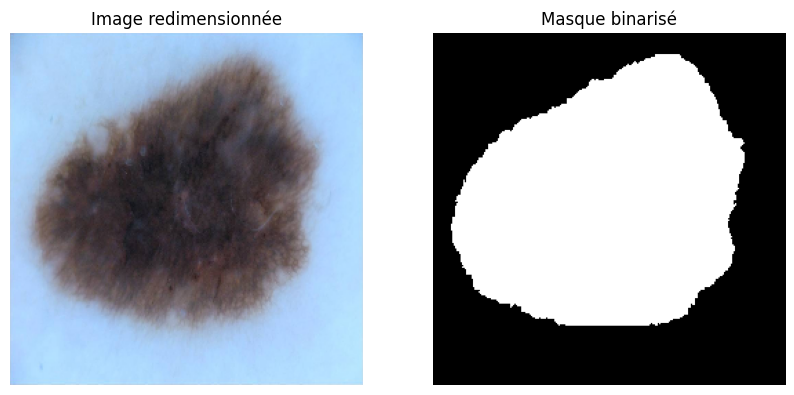

In [7]:
images, masks = train_dataset[0]
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Image redimensionnée")
plt.imshow(images[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Masque binarisé")
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.axis('off')

plt.show()

# Unet model

In [8]:
def conv_block(input_tensor, num_filters):
    x = Conv2D(num_filters, (3, 3), padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(num_filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    conv1 = conv_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = conv_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = conv_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = conv_block(pool3, 512)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = conv_block(pool4, 1024)

    up6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    up6 = concatenate([up6, conv4])
    conv6 = conv_block(up6, 512)

    up7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    up7 = concatenate([up7, conv3])
    conv7 = conv_block(up7, 256)

    up8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    up8 = concatenate([up8, conv2])
    conv8 = conv_block(up8, 128)

    up9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    up9 = concatenate([up9, conv1])
    conv9 = conv_block(up9, 64)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv9)
    return Model(inputs=[inputs], outputs=[outputs])

unet_model = build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# Metriques

In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3]) + K.sum(y_pred,[1,2,3]) - intersection
    return K.mean((intersection + smooth) / (union + smooth), axis=0)

In [10]:
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou, 'accuracy']
)

# Callbacks et entrainement

In [11]:
checkpoint_filepath = '/content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5'

callbacks = [
    ModelCheckpoint(checkpoint_filepath, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Début de l'entraînement de U-Net...")
history = unet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)

Début de l'entraînement de U-Net...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7959 - dice_coef: 0.5435 - iou: 0.3452 - loss: 0.4567
Epoch 1: val_loss improved from None to 0.66310, saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5



Epoch 1: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 465s 5s/step - accuracy: 0.8449 - dice_coef: 0.6255 - iou: 0.4177 - loss: 0.3769 - val_accuracy: 0.7631 - val_dice_coef: 0.3316 - val_iou: 0.1871 - val_loss: 0.6631 - learning_rate: 1.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9059 - dice_coef: 0.7315 - iou: 0.5089 - loss: 0.2692
Epoch 2: val_loss did not improve from 0.66310
82/82 ━━━━━━━━━━━━━━━━━━━━ 376s 5s/step - accuracy: 0.9108 - dice_coef: 0.7443 - iou: 0.5267 - loss: 0.2556 - val_accuracy: 0.7496 - val_dice_coef: 0.2016 - val_iou: 0.1113 - val_loss: 0.7770 - learning_rate: 1.0000e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9270 - dice_coef: 0.7800 - iou: 0.5645 - loss: 0.2177
Epoch 3: val_loss improved from 0.66310 to 0.43078, saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5



Epoch 3: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.9253 - dice_coef: 0.7795 - iou: 0.5671 - loss: 0.2175 - val_accuracy: 0.8291 - val_dice_coef: 0.5710 - val_iou: 0.4221 - val_loss: 0.4308 - learning_rate: 1.0000e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9273 - dice_coef: 0.7897 - iou: 0.5922 - loss: 0.2086
Epoch 4: val_loss improved from 0.43078 to 0.25821, saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5


...


Epoch 5: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.9364 - dice_coef: 0.8224 - iou: 0.6330 - loss: 0.1780 - val_accuracy: 0.8806 - val_dice_coef: 0.7607 - val_iou: 0.5950 - val_loss: 0.2431 - learning_rate: 1.0000e-04
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9385 - dice_coef: 0.8212 - iou: 0.6326 - loss: 0.1745
Epoch 6: val_loss did not improve from 0.24315
82/82 ━━━━━━━━━━━━━━━━━━━━ 380s 5s/step - accuracy: 0.9386 - dice_coef: 0.8272 - iou: 0.6459 - loss: 0.1695 - val_accuracy: 0.8921 - val_dice_coef: 0.7307 - val_iou: 0.5885 - val_loss: 0.2444 - learning_rate: 1.0000e-04
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9367 - dice_coef: 0.8279 - iou: 0.6553 - loss: 0.1721
Epoch 7: val_loss improved from 0.24315 to 0.16844, saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5



Epoch 7: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.9380 - dice_coef: 0.8318 - iou: 0.6594 - loss: 0.1681 - val_accuracy: 0.9194 - val_dice_coef: 0.8506 - val_iou: 0.7368 - val_loss: 0.1684 - learning_rate: 1.0000e-04
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9405 - dice_coef: 0.8448 - iou: 0.6834 - loss: 0.1546
Epoch 8: val_loss did not improve from 0.16844
82/82 ━━━━━━━━━━━━━━━━━━━━ 376s 5s/step - accuracy: 0.9415 - dice_coef: 0.8400 - iou: 0.6736 - loss: 0.1574 - val_accuracy: 0.8923 - val_dice_coef: 0.7805 - val_iou: 0.6310 - val_loss: 0.1935 - learning_rate: 1.0000e-04
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9426 - dice_coef: 0.8457 - iou: 0.6923 - loss: 0.1481
Epoch 9: val_loss did not improve from 0.16844
82/82 ━━━━━━━━━━━━━━━━━━━━ 378s 5s/step - accuracy: 0.9424 - dice_coef: 0.8403 - iou: 0.6847 - loss: 0.1524 - val_accuracy: 0.9087 - val


Epoch 10: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.9423 - dice_coef: 0.8476 - iou: 0.6939 - loss: 0.1513 - val_accuracy: 0.9192 - val_dice_coef: 0.8571 - val_iou: 0.7408 - val_loss: 0.1570 - learning_rate: 1.0000e-04
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9449 - dice_coef: 0.8557 - iou: 0.7131 - loss: 0.1445
Epoch 11: val_loss did not improve from 0.15704
82/82 ━━━━━━━━━━━━━━━━━━━━ 371s 5s/step - accuracy: 0.9462 - dice_coef: 0.8604 - iou: 0.7143 - loss: 0.1403 - val_accuracy: 0.9083 - val_dice_coef: 0.8379 - val_iou: 0.6974 - val_loss: 0.1714 - learning_rate: 1.0000e-04
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9470 - dice_coef: 0.8510 - iou: 0.7007 - loss: 0.1431
Epoch 12: val_loss improved from 0.15704 to 0.14675, saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5



Epoch 12: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 386s 5s/step - accuracy: 0.9453 - dice_coef: 0.8554 - iou: 0.7124 - loss: 0.1417 - val_accuracy: 0.9259 - val_dice_coef: 0.8423 - val_iou: 0.7382 - val_loss: 0.1468 - learning_rate: 1.0000e-04
Epoch 13/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9462 - dice_coef: 0.8689 - iou: 0.7342 - loss: 0.1309
Epoch 13: val_loss did not improve from 0.14675
82/82 ━━━━━━━━━━━━━━━━━━━━ 380s 5s/step - accuracy: 0.9462 - dice_coef: 0.8607 - iou: 0.7207 - loss: 0.1384 - val_accuracy: 0.9109 - val_dice_coef: 0.8444 - val_iou: 0.7425 - val_loss: 0.1797 - learning_rate: 1.0000e-04
Epoch 14/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9434 - dice_coef: 0.8559 - iou: 0.7240 - loss: 0.1424
Epoch 14: val_loss did not improve from 0.14675
82/82 ━━━━━━━━━━━━━━━━━━━━ 371s 5s/step - accuracy: 0.9475 - dice_coef: 0.8661 - iou: 0.7319 - loss: 0.1330 - val_accuracy: 0.9172 


Epoch 16: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.9511 - dice_coef: 0.8786 - iou: 0.7564 - loss: 0.1224 - val_accuracy: 0.9280 - val_dice_coef: 0.8522 - val_iou: 0.7575 - val_loss: 0.1415 - learning_rate: 1.0000e-04
Epoch 17/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9506 - dice_coef: 0.8783 - iou: 0.7569 - loss: 0.1216
Epoch 17: val_loss did not improve from 0.14147
82/82 ━━━━━━━━━━━━━━━━━━━━ 380s 5s/step - accuracy: 0.9520 - dice_coef: 0.8788 - iou: 0.7549 - loss: 0.1202 - val_accuracy: 0.9211 - val_dice_coef: 0.8556 - val_iou: 0.7768 - val_loss: 0.1558 - learning_rate: 1.0000e-04
Epoch 18/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9472 - dice_coef: 0.8645 - iou: 0.7410 - loss: 0.1348
Epoch 18: val_loss did not improve from 0.14147
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.9481 - dice_coef: 0.8672 - iou: 0.7440 - loss: 0.1298 - val_accuracy: 0.8448 

Courbes d'apprentissage

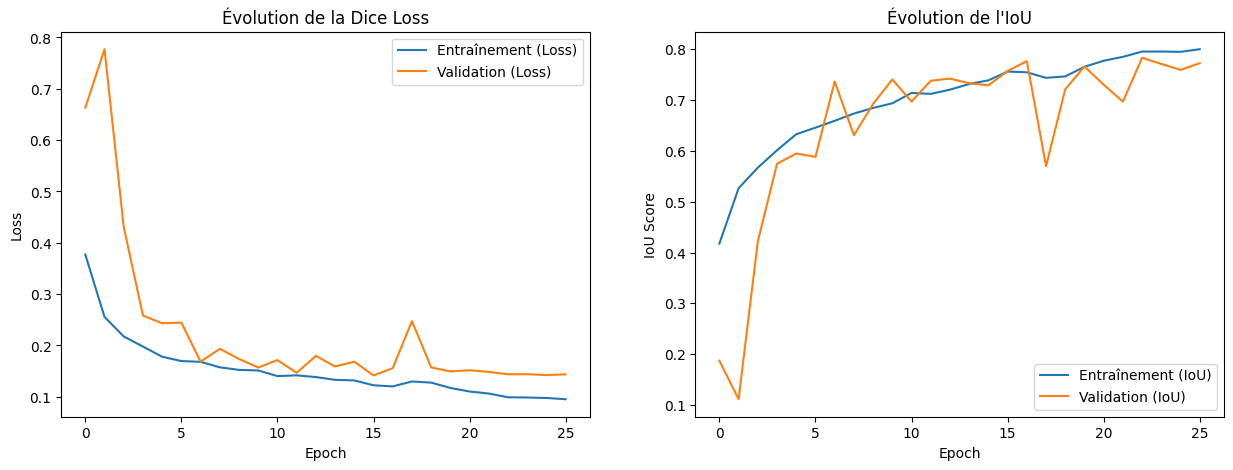

In [13]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Entraînement (Loss)')
    ax1.plot(history.history['val_loss'], label='Validation (Loss)')
    ax1.set_title('Évolution de la Dice Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['iou'], label='Entraînement (IoU)')
    ax2.plot(history.history['val_iou'], label='Validation (IoU)')
    ax2.set_title('Évolution de l\'IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU Score')
    ax2.legend()

    plt.show()

plot_training_history(history)

# Visualisation des prédictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


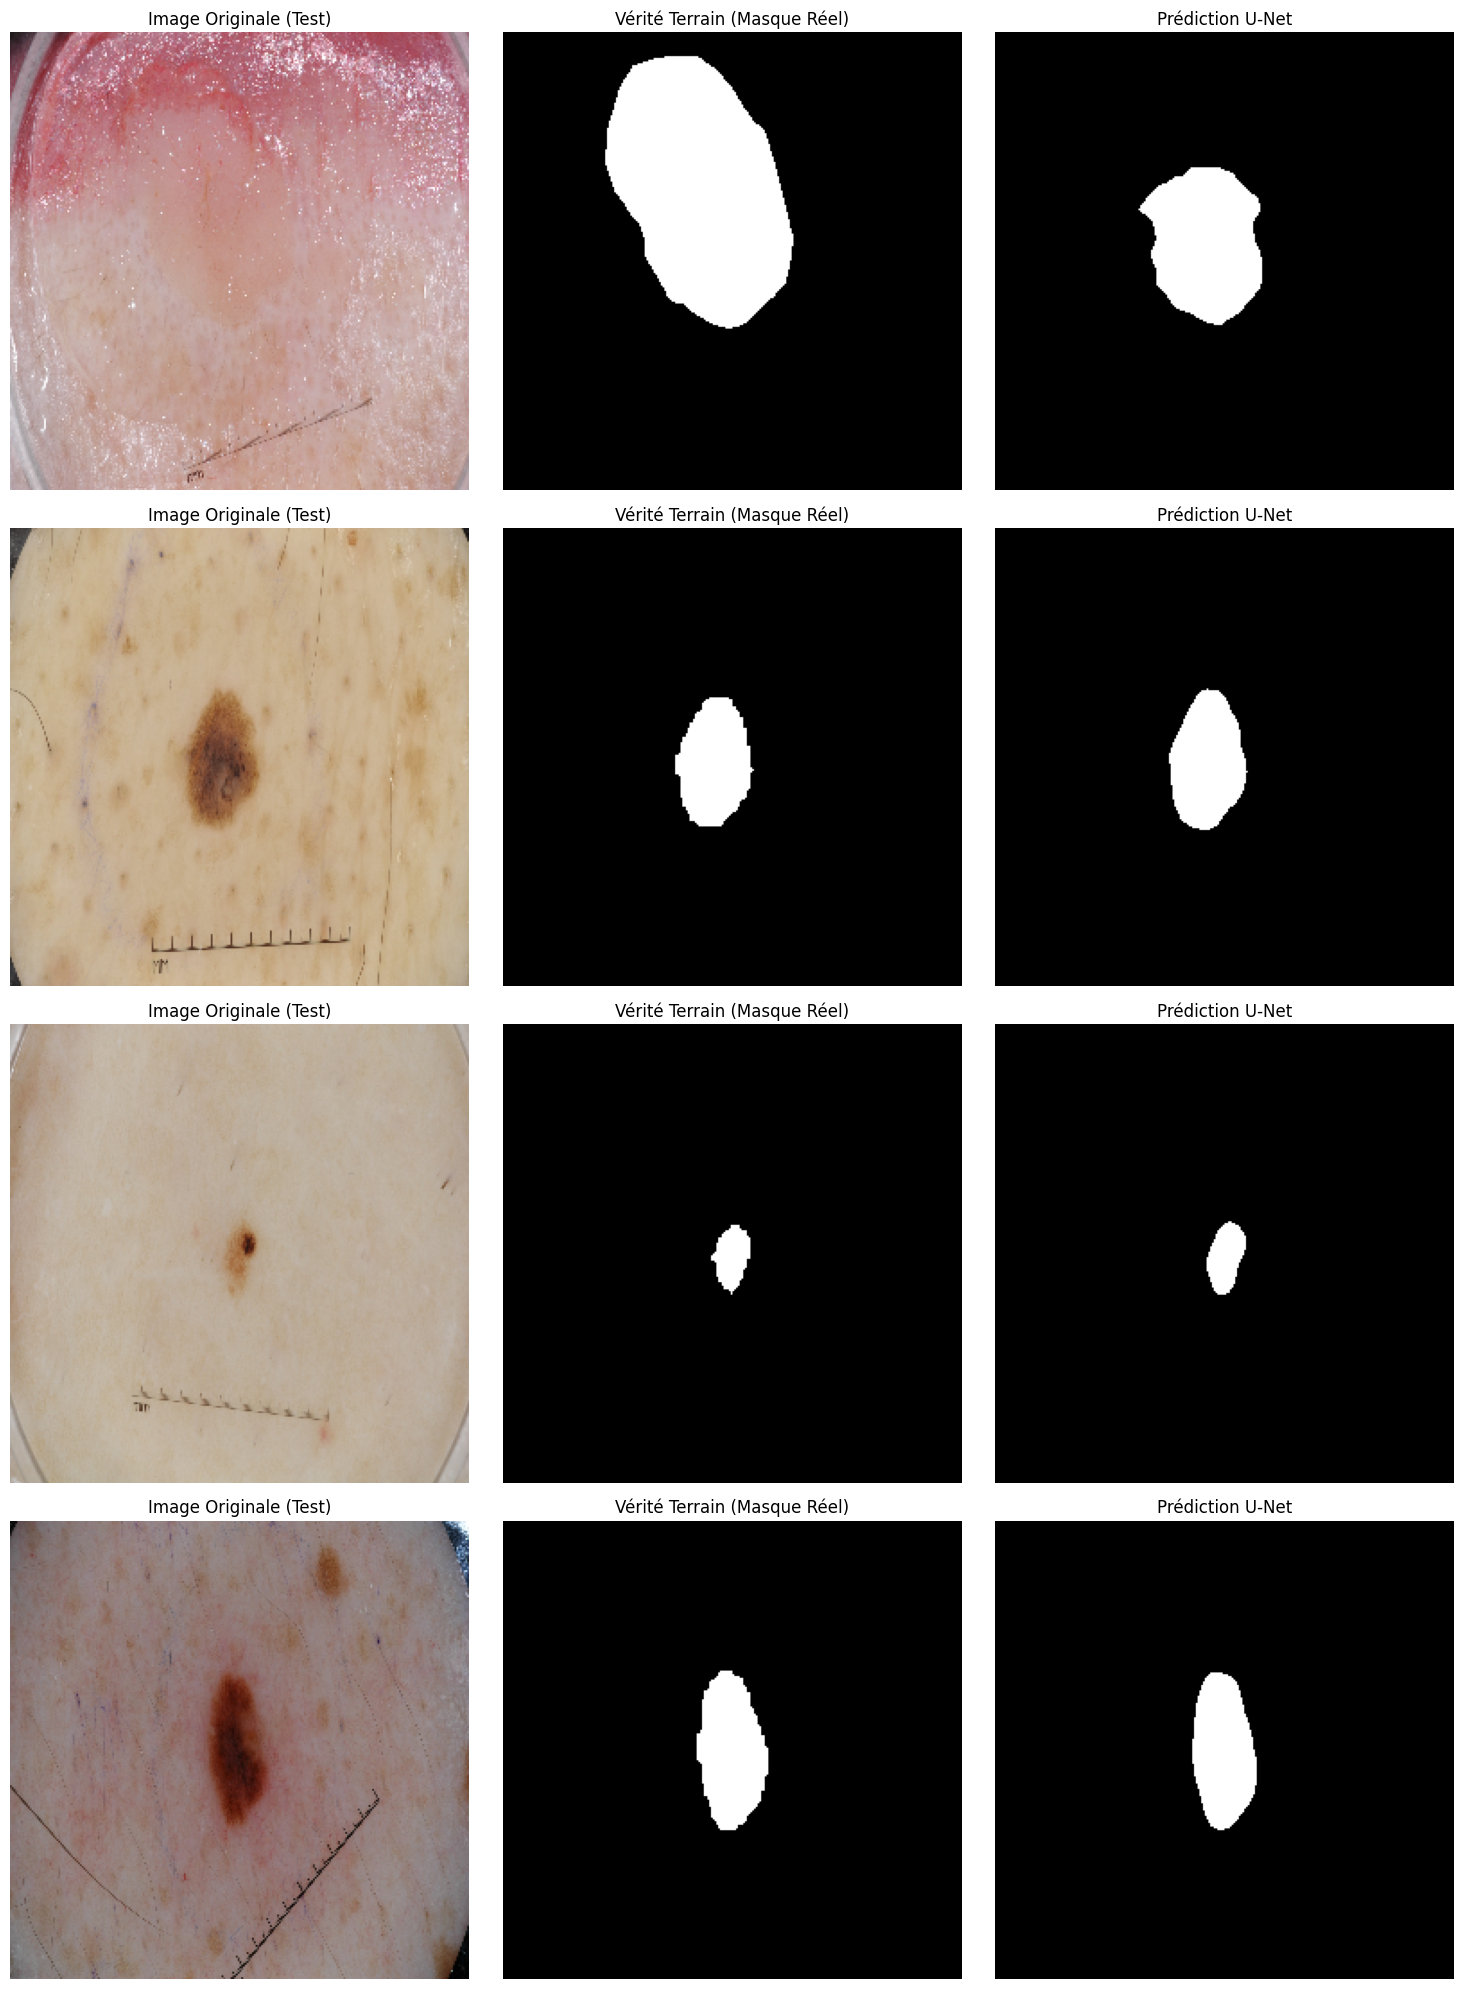

In [14]:
def visualize_predictions(dataset, model, num_samples=3):
    images, masks = dataset[0]
    predictions = model.predict(images[:num_samples])
    preds_bin = (predictions > 0.5).astype(np.float32)

    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.title("Image Originale (Test)")
        plt.imshow(images[i])
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.title("Vérité Terrain (Masque Réel)")
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.title("Prédiction U-Net")
        plt.imshow(preds_bin[i].squeeze(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(test_dataset, unet_model, num_samples=4)

# Traçabilité des metriques et test

✅ Historique d'entraînement sauvegardé dans : /content/drive/MyDrive/P9/Src/Experiences/Unet/unet_training_history.csv

Évaluation sur l'ensemble de Test...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9119 - dice_coef: 0.8349 - iou: 0.7527 - loss: 0.1657
loss: 0.1657
compile_metrics: 0.8349
✅ Scores de test sauvegardés dans : /content/drive/MyDrive/P9/Src/Experiences/Unet/unet_test_scores.txt
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ Image de prédictions sauvegardée dans : /content/drive/MyDrive/P9/Src/Experiences/Unet/unet_test_predictions.png


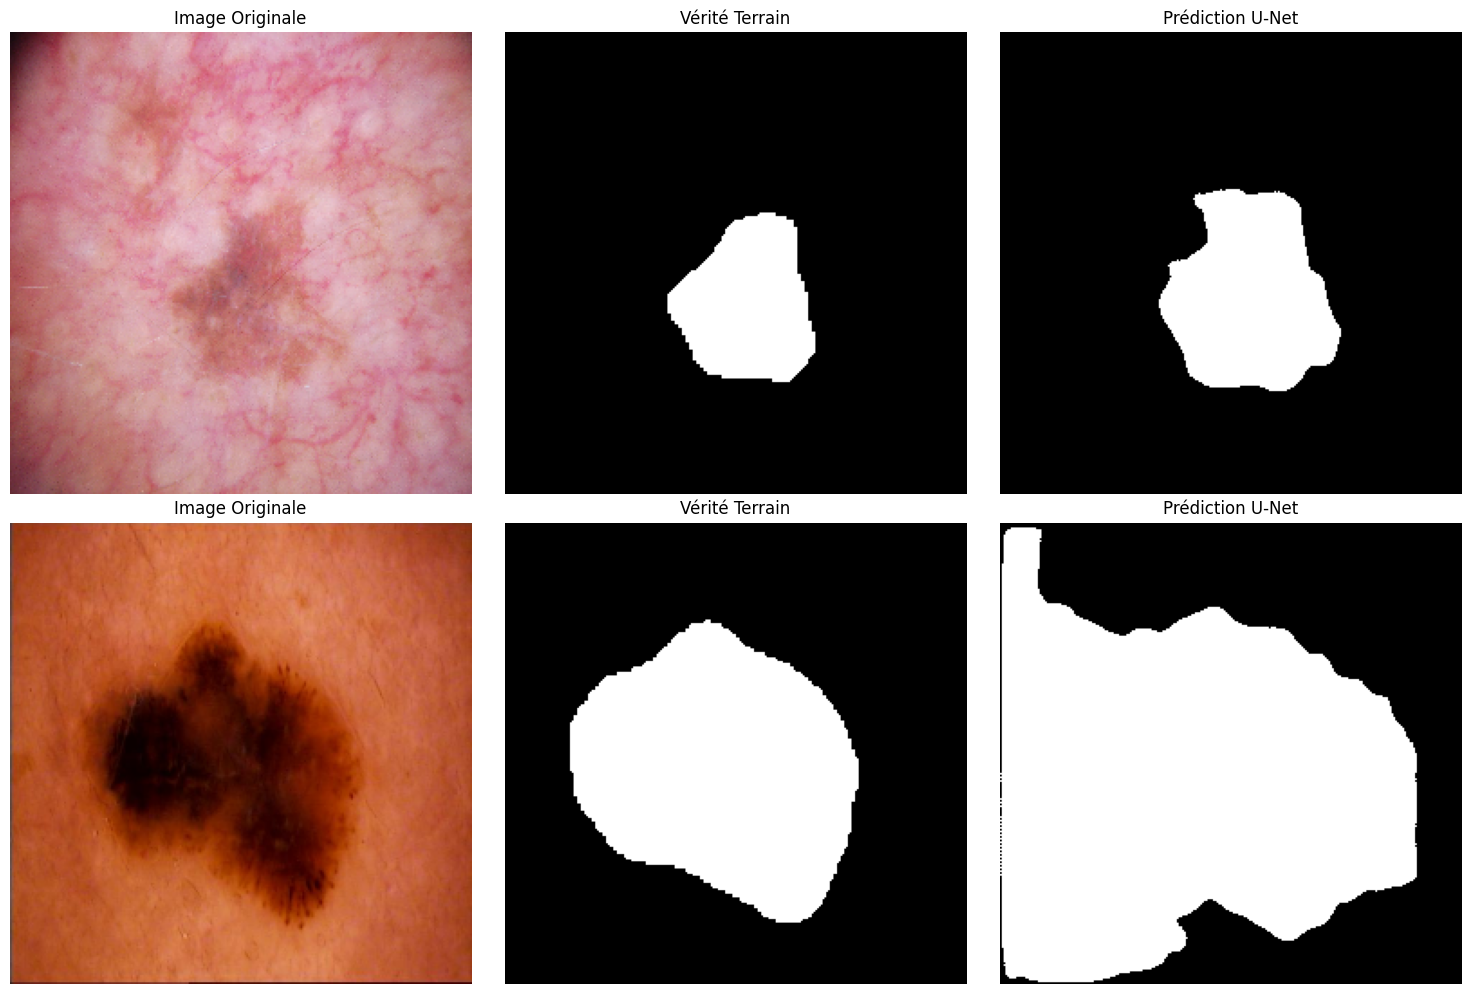

In [15]:
exp_dir = '/content/drive/MyDrive/P9/Src/Experiences/Unet'
os.makedirs(exp_dir, exist_ok=True)

history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(exp_dir, 'unet_training_history.csv')
history_df.to_csv(history_csv_path, index=False)
print(f"✅ Historique d'entraînement sauvegardé dans : {history_csv_path}")

print("\nÉvaluation sur l'ensemble de Test...")
unet_model.load_weights(checkpoint_filepath)
test_results = unet_model.evaluate(test_dataset, verbose=1)
metrics_names = unet_model.metrics_names

test_scores_path = os.path.join(exp_dir, 'unet_test_scores.txt')
with open(test_scores_path, 'w') as f:
    f.write("=== RÉSULTATS DE U-NET SUR ISIC 2018 (TEST SET) ===\n")
    for name, score in zip(metrics_names, test_results):
        f.write(f"{name}: {score:.4f}\n")
        print(f"{name}: {score:.4f}")
print(f"✅ Scores de test sauvegardés dans : {test_scores_path}")

images, masks = test_dataset[0]
predictions = unet_model.predict(images[:2])
preds_bin = (predictions > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))
for i in range(2):
    plt.subplot(2, 3, i*3 + 1)
    plt.title("Image Originale")
    plt.imshow(images[i])
    plt.axis('off')

    plt.subplot(2, 3, i*3 + 2)
    plt.title("Vérité Terrain")
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, i*3 + 3)
    plt.title("Prédiction U-Net")
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
predictions_img_path = os.path.join(exp_dir, 'unet_test_predictions.png')
plt.savefig(predictions_img_path)
print(f"✅ Image de prédictions sauvegardée dans : {predictions_img_path}")
plt.show()